# Cross-day comparison: 1 / 2 / 3 / 4-day 10% formalin-fixed decell tissue

All runs (FORCE + LENGTH per sample) processed through the **same pipeline** as the per-day
notebooks: align scope to potentiostat -> MAD outlier filter -> map to applied V ->
**global linear-slippage correction** -> final cycle (scan 3, most equilibrated) -> smooth.

**Replicates:** day 3 has two independent samples (`3-day t1`, `3-day t2`), drawn as separate
points/curves (take-2 dashed). This lets us see the *within-day spread* and judge whether a day's
value is reproducible. Correlations are fit on **all samples** (n=5: days 1,2,3,3,4), with the
per-day mean drawn as a large black-edged marker.

We test whether the final-cycle **swing** (max - min) of stress (MPa, FORCE) and strain (%, LENGTH)
tracks fixation day.

In [1]:
BASE = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'

In [2]:
# Config: per-SAMPLE file map + calibration. Geometry comes from sizes.csv.
import os, io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import stats

SCAN_RATE_V_PER_S    = 0.0025
FORCE_GAIN_MN_PER_V  = 56.7        # 1x gain, all days
LENGTH_COEF_MM_PER_V = -0.4130     # 1x gain, all days
WINDOW, K            = 41, 5.0
V_TOP                = 0.98
SMOOTH_WINDOW, SAVGOL_POLY = 101, 3

sizes = pd.read_csv(os.path.join(BASE, 'sizes.csv')).set_index('formalin_fixation_time')

# One entry per physical sample. 'key' indexes sizes.csv; 'rep' distinguishes same-day replicates.
SAMPLES = [
    dict(sid='1_DAY', day=1, key='1_DAY', label='1-day', rep=0,
         force_scope ='1day_10%_formalin_fixed_FORCE_scope_log_20260618_115506.csv',
         length_scope='1day_10%_formalin_fixed_LENGTH_scope_log_20260618_131839.csv',
         force_poten ='potentiostat/06.18.26-1Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         length_poten='potentiostat/06.18.26-1Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='2_DAY', day=2, key='2_DAY', label='2-day', rep=0,
         force_scope ='2day_10%_formalin_fixed_FORCE_scope_log_20260615_134504_2Day_10%_formalin_2.5mVperSecond_FORCE.csv',
         length_scope='2day_10%_formalin_fixed_LENGTHscope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv',
         force_poten ='potentiostat/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         length_poten='potentiostat/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY', day=3, key='3_DAY', label='3-day t1', rep=0,
         force_scope ='3day_10%_formalin_fixed_FORCE_scope_log_20260617_135652.csv',
         length_scope='3day_10%_formalin_fixed_LENGTH_scope_log_20260617_153455.csv',
         force_poten ='potentiostat/06.17.26-3Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length_poten='potentiostat/06.17.26-3Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY_take_2', day=3, key='3_DAY_take_2', label='3-day t2', rep=1,
         force_scope ='3day_take2_10%)formalin_fixed_FORCE_scope_log_20260619_135752.csv',
         length_scope='3day_take2_10%_formalin_fixed_LENGTH_scope_log_20260619_152237.csv',
         force_poten ='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length_poten='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='4_DAY', day=4, key='4_DAY', label='4-day', rep=0,
         force_scope ='4day_10%_formalin_fixed_FORCE_scope_log_20260616_141521.csv',
         length_scope='4day_10%_formalin_fixed_LENGTH_scope_log_20260616_154045.csv',
         force_poten ='potentiostat/06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length_poten='potentiostat/06.16.26-4Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
]
DAY_COLOR = {1: '#9467bd', 2: '#1f77b4', 3: '#d62728', 4: '#2ca02c'}
REP_LS = {0: '-', 1: '--'}        # take-2 replicate drawn dashed

In [3]:
# Shared processing -- identical math to the per-day notebooks.
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad = mad.clip(lower=max(np.nanstd(x) * 1e-3, 1e-9))
    return (abs_dev > k * mad).values

def savgol_per_cycle(df, col, window=SMOOTH_WINDOW, poly=SAVGOL_POLY):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); y = sub[col].values; n = len(y)
        if n < 3:
            out.loc[sub.index] = y; continue
        w = min(window, n); w -= (w % 2 == 0)
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out

def load_poten(path):
    text = open(path, 'rb').read().decode('utf-16').replace('﻿', '')
    rows = [r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n = len(rows[0]) // 2
    cols = []
    for s in range(n):
        cols += [f'v{s+1}', f'i{s+1}_uA']
    df = pd.DataFrame([[float(x) for x in r[:2*n]] for r in rows], columns=cols)
    return df, n

def process(scope_csv, poten_csv, channel, coef):
    """Returns (poten df, n_scans, slippage-corrected scope df). scope df has v_applied,
    cycle, value_corr (physical units), smooth_corr (savgol)."""
    poten, n = load_poten(os.path.join(BASE, poten_csv))
    v1 = poten['v1'].values; turn = int(np.argmin(v1))
    DT = abs(v1[0] - v1[turn]) / turn / SCAN_RATE_V_PER_S
    per = len(poten) * DT; total = n * per
    t_scan = np.arange(len(poten)) * DT
    t_full = np.concatenate([t_scan + s*per for s in range(n)])
    v_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n)])

    scope = pd.read_csv(os.path.join(BASE, scope_csv)); scope['t_exp'] = scope['elapsed_s']
    s_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= total)].copy()
    s_in = s_in.loc[~mark_outliers(s_in[channel].values, WINDOW, K)].copy()
    s_in['v_applied'] = np.interp(s_in['t_exp'].values, t_full, v_full)
    s_in['cycle'] = np.clip((s_in['t_exp'].values // per).astype(int), 0, n-1)

    t0 = s_in['t_exp'].min()
    top = s_in[s_in['v_applied'] >= V_TOP]
    b, a = np.polyfit(top['t_exp'].values, top[channel].values, 1)   # linear slippage
    s_in['corrected']  = s_in[channel] - b * (s_in['t_exp'] - t0)
    s_in['value_corr'] = s_in['corrected'] * coef
    s_in['smooth_corr'] = savgol_per_cycle(s_in, 'value_corr')
    return poten, n, s_in

In [4]:
# Process every sample; collect final-cycle series + deltas keyed by sample id (sid).
records = []
final_force_curves, final_length_curves = {}, {}   # sid -> (v_applied, stress_MPa / strain_pct)
final_force_cv, final_length_cv = {}, {}            # sid -> (V, I_uA) potentiostat final cycle

for s in SAMPLES:
    sid, day = s['sid'], s['day']
    g = sizes.loc[s['key']]
    L0, W, T = float(g['length(mm)']), float(g['width(mm)']), float(g['thickness(mm)'])
    area = W * T

    pf, nf, sf = process(s['force_scope'], s['force_poten'], 'ch2_MEAN_V', FORCE_GAIN_MN_PER_V)
    subf = sf[sf['cycle'] == nf - 1].sort_values('v_applied')
    stress = subf['smooth_corr'] / area / 1000.0       # mN -> MPa
    final_force_curves[sid] = (subf['v_applied'].values, stress.values)
    final_force_cv[sid]     = (pf[f'v{nf}'].values, pf[f'i{nf}_uA'].values)

    pl, nl, sl = process(s['length_scope'], s['length_poten'], 'ch1_MEAN_V', LENGTH_COEF_MM_PER_V)
    subl = sl[sl['cycle'] == nl - 1].sort_values('v_applied')
    strain = subl['smooth_corr'] / L0 * 100.0          # mm -> % strain
    final_length_curves[sid] = (subl['v_applied'].values, strain.values)
    final_length_cv[sid]     = (pl[f'v{nl}'].values, pl[f'i{nl}_uA'].values)

    records.append(dict(sid=sid, day=day, label=s['label'], L0_mm=L0, width_mm=W, thickness_mm=T,
                        area_mm2=round(area, 4),
                        stress_delta_MPa=float(stress.max() - stress.min()),
                        force_delta_mN=float(subf['smooth_corr'].max() - subf['smooth_corr'].min()),
                        strain_delta_pct=float(strain.max() - strain.min()),
                        dist_delta_mm=float(subl['smooth_corr'].max() - subl['smooth_corr'].min())))

summary = pd.DataFrame(records).sort_values(['day', 'sid']).reset_index(drop=True)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Final-cycle (scan 3) per-sample summary, slippage-corrected:')
summary

Final-cycle (scan 3) per-sample summary, slippage-corrected:


,sid,day,label,L0_mm,width_mm,thickness_mm,area_mm2,stress_delta_MPa,force_delta_mN,strain_delta_pct,dist_delta_mm
0,1_DAY,1,1-day,7.0000,4.0000,0.3600,1.4400,0.0096,13.8403,0.3523,0.0247
1,2_DAY,2,2-day,9.0000,2.8000,0.4500,1.2600,0.0187,23.5770,0.5298,0.0477
2,3_DAY,3,3-day t1,5.0000,3.1000,0.4260,1.3206,0.0090,11.8312,0.6613,0.0331
3,3_DAY_take_2,3,3-day t2,11.0000,2.5000,0.6960,1.7400,0.0046,8.0013,0.1106,0.0122
4,4_DAY,4,4-day,11.0000,3.4000,0.3740,1.2716,0.0229,29.1361,0.7095,0.0780


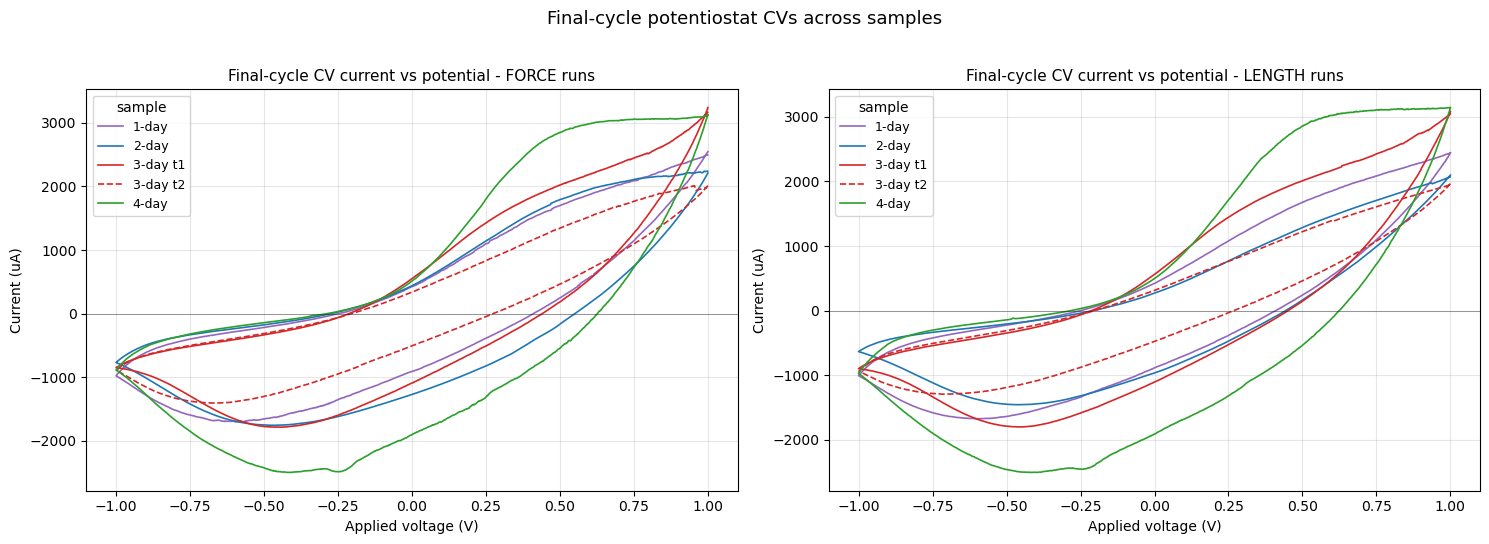

In [5]:
# Final-cycle potentiostat CVs overlaid (left FORCE runs, right LENGTH runs); take-2 dashed.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for s in SAMPLES:
    c, ls = DAY_COLOR[s['day']], REP_LS[s['rep']]
    v, i = final_force_cv[s['sid']];  axes[0].plot(v, i, color=c, ls=ls, lw=1.2, label=s['label'])
    v, i = final_length_cv[s['sid']]; axes[1].plot(v, i, color=c, ls=ls, lw=1.2, label=s['label'])
for ax, ttl in zip(axes, ['FORCE runs', 'LENGTH runs']):
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel('Applied voltage (V)'); ax.set_ylabel('Current (uA)')
    ax.grid(True, alpha=0.3); ax.legend(title='sample', fontsize=9)
    ax.set_title(f'Final-cycle CV current vs potential - {ttl}', fontsize=11)
fig.suptitle('Final-cycle potentiostat CVs across samples', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

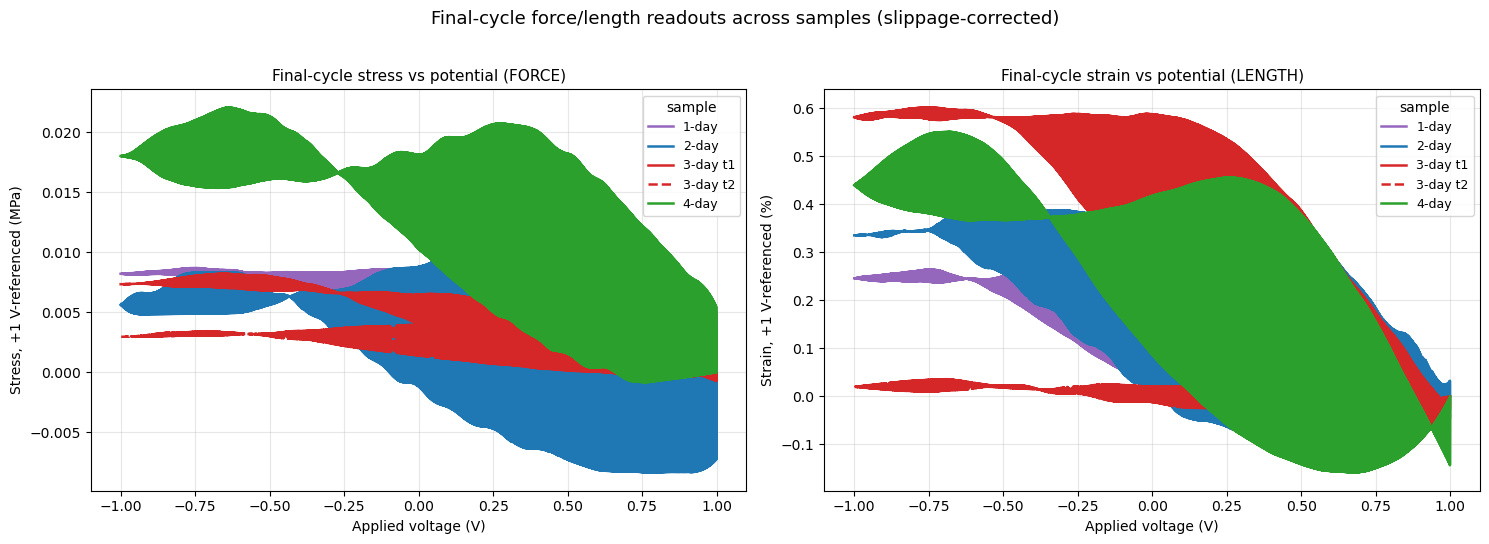

In [6]:
# Final-cycle mechanical readouts overlaid; each curve referenced to 0 at +1 V so swings compare.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for s in SAMPLES:
    c, ls = DAY_COLOR[s['day']], REP_LS[s['rep']]
    v, y = final_force_curves[s['sid']]; o = np.argsort(v)
    axes[0].plot(v[o], (y - y[np.argmax(v)])[o], color=c, ls=ls, lw=1.8, label=s['label'])
    v, y = final_length_curves[s['sid']]; o = np.argsort(v)
    axes[1].plot(v[o], (y - y[np.argmax(v)])[o], color=c, ls=ls, lw=1.8, label=s['label'])
axes[0].set_ylabel('Stress, +1 V-referenced (MPa)'); axes[0].set_title('Final-cycle stress vs potential (FORCE)', fontsize=11)
axes[1].set_ylabel('Strain, +1 V-referenced (%)');  axes[1].set_title('Final-cycle strain vs potential (LENGTH)', fontsize=11)
for ax in axes:
    ax.set_xlabel('Applied voltage (V)'); ax.grid(True, alpha=0.3); ax.legend(title='sample', fontsize=9)
fig.suptitle('Final-cycle force/length readouts across samples (slippage-corrected)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

Final-cycle swing (max - min), slippage-corrected:


,label,day,area_mm2,L0_mm,stress_delta_MPa,force_delta_mN,strain_delta_pct,dist_delta_mm
0,1-day,1,1.4400,7.0000,0.0096,13.8403,0.3523,0.0247
1,2-day,2,1.2600,9.0000,0.0187,23.5770,0.5298,0.0477
2,3-day t1,3,1.3206,5.0000,0.0090,11.8312,0.6613,0.0331
3,3-day t2,3,1.7400,11.0000,0.0046,8.0013,0.1106,0.0122
4,4-day,4,1.2716,11.0000,0.0229,29.1361,0.7095,0.0780


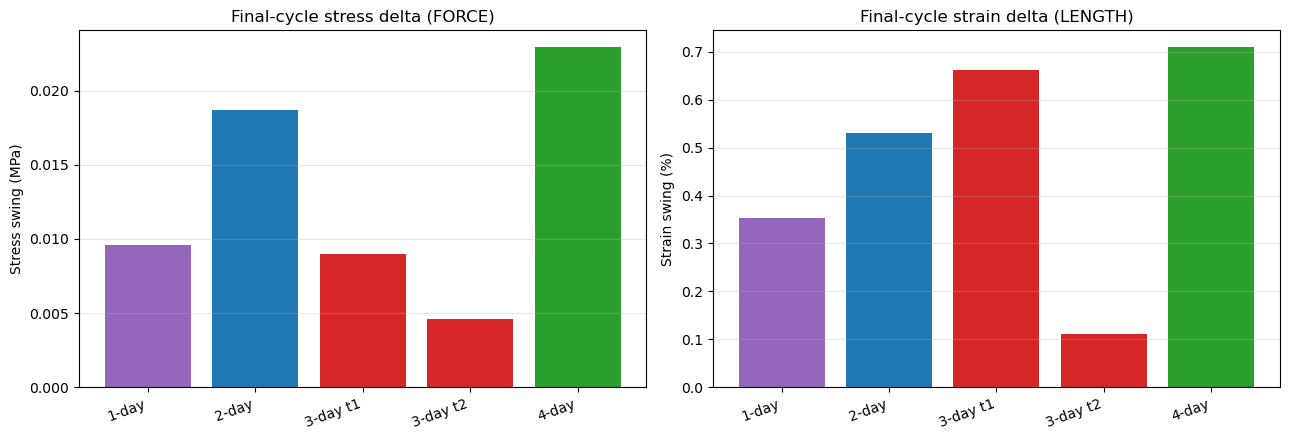

In [7]:
# Headline table + bars: final-cycle swing per sample (day 3 shows both replicates side by side).
delta_tbl = summary[['label', 'day', 'area_mm2', 'L0_mm', 'stress_delta_MPa', 'force_delta_mN',
                     'strain_delta_pct', 'dist_delta_mm']].copy()
print('Final-cycle swing (max - min), slippage-corrected:')
display(delta_tbl)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
xpos = np.arange(len(summary)); cols = [DAY_COLOR[d] for d in summary['day']]
axes[0].bar(xpos, summary['stress_delta_MPa'], color=cols)
axes[0].set_ylabel('Stress swing (MPa)'); axes[0].set_title('Final-cycle stress delta (FORCE)')
axes[1].bar(xpos, summary['strain_delta_pct'], color=cols)
axes[1].set_ylabel('Strain swing (%)'); axes[1].set_title('Final-cycle strain delta (LENGTH)')
for ax in axes:
    ax.set_xticks(xpos); ax.set_xticklabels(summary['label'], rotation=20, ha='right')
    ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

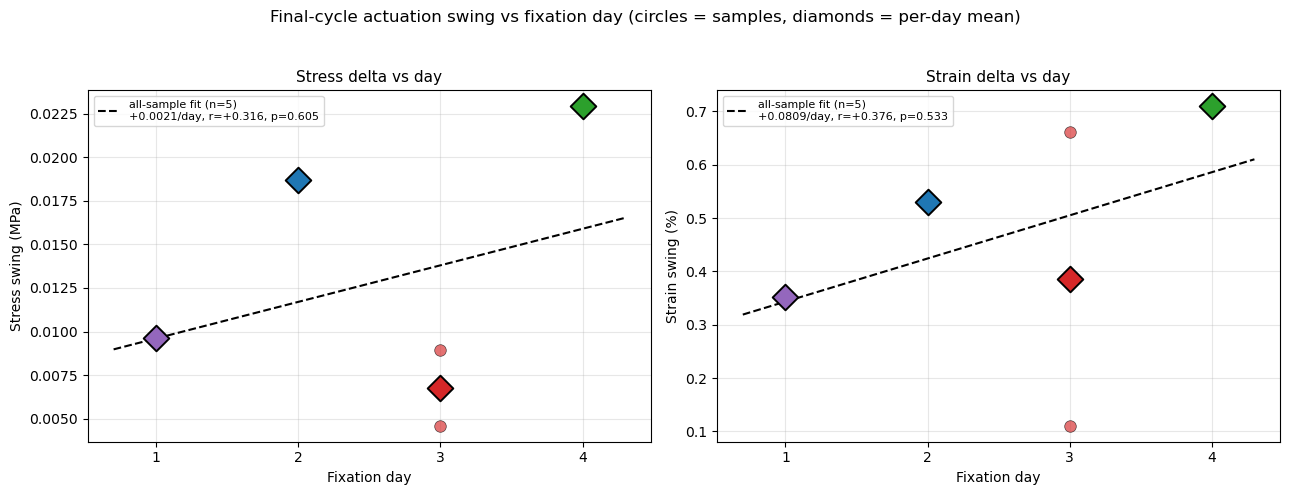

Stress delta vs day: all-sample r=+0.316 (p=0.605), day-mean r=+0.477, slope=+0.0021 MPa/day
Strain delta vs day: all-sample r=+0.376 (p=0.533), day-mean r=+0.736, slope=+0.0809 %/day
\nDay-3 replicate spread:
  stress delta: [0.008958975927728069, 0.004598472373645218] MPa  (spread 0.0044)
  strain delta: [0.6612556292269676, 0.11056696929541387] %   (spread 0.5507)


In [8]:
# Hypothesis test: does the final-cycle swing track fixation day? Fit on all samples (n=5),
# show per-day means as large markers. With replicates, day 3's spread feeds the residual honestly.
def corr_panel(ax, ycol, ylabel, title):
    x = summary['day'].values.astype(float); y = summary[ycol].values.astype(float)
    for _, row in summary.iterrows():
        ax.scatter(row['day'], row[ycol], s=70, color=DAY_COLOR[row['day']], ec='k', lw=0.5,
                   alpha=0.65, zorder=4)
    # per-day means (large markers)
    means = summary.groupby('day')[ycol].mean()
    for d, m in means.items():
        ax.scatter(d, m, s=170, color=DAY_COLOR[d], ec='k', lw=1.4, marker='D', zorder=5)
    slope, intercept, r, p, se = stats.linregress(x, y)
    xs = np.linspace(x.min() - 0.3, x.max() + 0.3, 50)
    ax.plot(xs, intercept + slope*xs, 'k--', lw=1.5,
            label=f'all-sample fit (n={len(x)})\n{slope:+.3g}/day, r={r:+.3f}, p={p:.3f}')
    rm, pm = stats.linregress(means.index.astype(float), means.values)[2:4]
    ax.set_xlabel('Fixation day'); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.set_xticks(sorted(summary['day'].unique())); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    return slope, r, p, rm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
s_slope, s_r, s_p, s_rm = corr_panel(axes[0], 'stress_delta_MPa', 'Stress swing (MPa)', 'Stress delta vs day')
e_slope, e_r, e_p, e_rm = corr_panel(axes[1], 'strain_delta_pct', 'Strain swing (%)', 'Strain delta vs day')
fig.suptitle('Final-cycle actuation swing vs fixation day (circles = samples, diamonds = per-day mean)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print(f'Stress delta vs day: all-sample r={s_r:+.3f} (p={s_p:.3f}), day-mean r={s_rm:+.3f}, slope={s_slope:+.4f} MPa/day')
print(f'Strain delta vs day: all-sample r={e_r:+.3f} (p={e_p:.3f}), day-mean r={e_rm:+.3f}, slope={e_slope:+.4f} %/day')

# Day-3 replicate spread (the whole point of take-2):
d3 = summary[summary['day'] == 3]
print(f'\\nDay-3 replicate spread:')
print(f'  stress delta: {d3["stress_delta_MPa"].tolist()} MPa  (spread {d3["stress_delta_MPa"].max()-d3["stress_delta_MPa"].min():.4f})')
print(f'  strain delta: {d3["strain_delta_pct"].tolist()} %   (spread {d3["strain_delta_pct"].max()-d3["strain_delta_pct"].min():.4f})')

## Reading the results

- **Readout overlays** are referenced to 0 at +1 V so the actuation swing is directly comparable;
  the two day-3 curves (solid = take1, dashed = take2) show run-to-run reproducibility.
- **Delta bars** put the day-3 replicates side by side — compare their heights to gauge noise before
  reading the across-day trend.
- **Correlation panels** fit swing vs day on all samples (circles), with per-day means as diamonds.
  Because day 3 now has two samples, its within-day spread feeds the fit honestly rather than being
  hidden behind a single point.
- Still only one sample for days 1/2/4 — treat r/p as descriptive. The day-3 replicate is the first
  real handle on measurement noise; add replicates at the other days to convert these trends into
  defensible statistics.